# Online Retail Case Study
## Objective is to group customers based on the invoice data that has been provided to us

**Overview**<br>
<a href="https://archive.ics.uci.edu/ml/datasets/online+retail">Online retail is a transnational data set</a> which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail. The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.

The steps are broadly:
1. Read and understand the data
2. Clean the data
3. Prepare the data for modelling
4. Modelling
5. Final analysis and recommendations

In [1]:
# Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import sklearn
from sklearn.cluster import KMeans

## 1. Read the data

In [2]:
df = pd.read_csv("Online_Retail.csv", encoding="ISO-8859-1", header=0, sep=",")

In [3]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01-12-2010 08:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01-12-2010 08:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,01-12-2010 08:34,1.69,13047.0,United Kingdom


In [4]:
df["InvoiceDate"]

0         01-12-2010 08:26
1         01-12-2010 08:26
2         01-12-2010 08:26
3         01-12-2010 08:26
4         01-12-2010 08:26
                ...       
541904    09-12-2011 12:50
541905    09-12-2011 12:50
541906    09-12-2011 12:50
541907    09-12-2011 12:50
541908    09-12-2011 12:50
Name: InvoiceDate, Length: 541909, dtype: object

In [5]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%d-%m-%Y %H:%M")

In [6]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [7]:
frame = df.groupby("Description")
frame["Quantity"].value_counts()

Description                     Quantity
 4 PURPLE FLOCK DINNER CANDLES   1          19
                                 2           7
                                 12          6
                                 3           3
                                 4           3
                                            ..
wrongly marked carton 22804     -256         1
wrongly marked. 23343 in box    -3100        1
wrongly sold (22719) barcode     170         1
wrongly sold as sets            -600         1
wrongly sold sets               -975         1
Name: count, Length: 44672, dtype: int64

In [8]:
df["Total"] = df["UnitPrice"] * df["Quantity"]

In [9]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08


In [10]:
df.StockCode.nunique()

4070

In [11]:
df[df["Quantity"] < 0]["Quantity"].shape

(10624,)

## 2. Clean the data


In [12]:
dfAnalysis = df.copy()
dfAnalysis = df[df["Quantity"] >= 0]

In [13]:
dfAnalysis.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08


In [14]:
dfAnalysis = dfAnalysis[dfAnalysis["UnitPrice"] > 0]

In [15]:
dfAnalysis.shape

(530104, 9)

In [16]:
df.shape

(541909, 9)

In [17]:
def shape_reduction(df1, df2):
    return str(100 * (1 - df1.shape[0] / df2.shape[0])) + "%"

In [18]:
print(shape_reduction(dfAnalysis, df))

2.178410028251976%


### We will be using the RFM Model to indentify customers based on the invoice data given
1. R-> Recency if they made any purchase in the past one month
2. F-> Frequency how many purchases did they make in the past one year
3. M-> Monetary Value how much did they spend

In [19]:
dfAnalysis["CustomerID"].nunique()

4338

In [20]:
dfAnalysis["CustomerID"].value_counts()

CustomerID
17841.0    7847
14911.0    5675
14096.0    5111
12748.0    4595
14606.0    2700
           ... 
18184.0       1
13185.0       1
16073.0       1
17948.0       1
17846.0       1
Name: count, Length: 4338, dtype: int64

In [21]:
group_by_customer_id = dfAnalysis.groupby("CustomerID")

In [22]:
dfAnalysis.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132220
Country             0
Total               0
dtype: int64

In [23]:
dfAnalysis = dfAnalysis[~dfAnalysis["CustomerID"].isna()]

In [24]:
int(dfAnalysis.isna().sum().any())

0

In [25]:
# dfAnalysis.to_excel('Online_Retail.xlsx')

In [26]:
customers = dfAnalysis.groupby("CustomerID")
customers["Total"].sum()

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2094.88
18287.0     1837.28
Name: Total, Length: 4338, dtype: float64

In [27]:
dfAnalysis.shape

(397884, 9)

##  3. Prepare the Data for modelling
- We want to do clustering based on Recency, Frequency,Total, Customer_IDm

In [28]:
dfAnalysis.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08


In [29]:
dfAnalysis["InvoiceDate"].dt.month.value_counts()

InvoiceDate
11    64531
10    49554
12    43461
9     40028
5     28320
6     27185
3     27175
8     27007
7     26825
4     22642
1     21229
2     19927
Name: count, dtype: int64

In [30]:
dfAnalysis["InvoiceNo"].dtype

dtype('O')

In [31]:
import warnings

warnings.filterwarnings("ignore")

In [32]:
dfAnalysis["InvoiceNo"] = pd.to_numeric(
    dfAnalysis["InvoiceNo"], downcast="integer", errors="coerce"
)

In [33]:
dfAnalysis.dtypes

InvoiceNo               int32
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
Total                 float64
dtype: object

In [34]:
customers_amount_df = customers["InvoiceNo"].count()
customers_amount_df = customers_amount_df.reset_index()
customers_amount_df.head()

,CustomerID,InvoiceNo
0,12346.0,1
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


In [35]:
# Amount
customers_amount = (customers["Total"].sum()).reset_index()
customers_amount.head()

,CustomerID,Total
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [36]:
customers_amount_df = pd.merge(
    customers_amount_df, customers_amount, on="CustomerID", how="inner"
)
customers_amount_df.head(10)

,CustomerID,InvoiceNo,Total
0,12346.0,1,77183.60
1,12347.0,182,4310.00
2,12348.0,31,1797.24
3,12349.0,73,1757.55
4,12350.0,17,334.40
5,12352.0,85,2506.04
6,12353.0,4,89.00
7,12354.0,58,1079.40
8,12355.0,13,459.40
9,12356.0,59,2811.43


In [37]:
max_date = max(dfAnalysis["InvoiceDate"])
dfAnalysis["diff"] = max_date - dfAnalysis["InvoiceDate"]
dfAnalysis.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total,diff
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373 days 04:24:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373 days 04:24:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30,373 days 04:24:00
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50,373 days 04:24:00
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,373 days 04:22:00
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,373 days 04:22:00
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,373 days 04:16:00


In [38]:
# recency
recency = customers["diff"].min()
recency = recency.reset_index()
recency.head()

,CustomerID,diff
0,12346.0,325 days 02:49:00
1,12347.0,1 days 20:58:00
2,12348.0,74 days 23:37:00
3,12349.0,18 days 02:59:00
4,12350.0,309 days 20:49:00


In [39]:
grouped_df = pd.merge(customers_amount_df, recency, on="CustomerID", how="inner")
print(grouped_df.shape)
grouped_df.head(10)

(4338, 4)


,CustomerID,InvoiceNo,Total,diff
0,12346.0,1,77183.60,325 days 02:49:00
1,12347.0,182,4310.00,1 days 20:58:00
2,12348.0,31,1797.24,74 days 23:37:00
3,12349.0,73,1757.55,18 days 02:59:00
4,12350.0,17,334.40,309 days 20:49:00
5,12352.0,85,2506.04,35 days 22:13:00
6,12353.0,4,89.00,203 days 19:03:00
7,12354.0,58,1079.40,231 days 23:39:00
8,12355.0,13,459.40,213 days 23:01:00
9,12356.0,59,2811.43,22 days 04:10:00


In [40]:
grouped_df.columns = ["CustomerID", "frequency", "monetary", "recency"]
grouped_df.head(10)

,CustomerID,frequency,monetary,recency
0,12346.0,1,77183.60,325 days 02:49:00
1,12347.0,182,4310.00,1 days 20:58:00
2,12348.0,31,1797.24,74 days 23:37:00
3,12349.0,73,1757.55,18 days 02:59:00
4,12350.0,17,334.40,309 days 20:49:00
5,12352.0,85,2506.04,35 days 22:13:00
6,12353.0,4,89.00,203 days 19:03:00
7,12354.0,58,1079.40,231 days 23:39:00
8,12355.0,13,459.40,213 days 23:01:00
9,12356.0,59,2811.43,22 days 04:10:00


In [41]:
grouped_df["recency"] = grouped_df["recency"].dt.days

In [42]:
grouped_df.head(10)

,CustomerID,frequency,monetary,recency
0,12346.0,1,77183.60,325
1,12347.0,182,4310.00,1
2,12348.0,31,1797.24,74
3,12349.0,73,1757.55,18
4,12350.0,17,334.40,309
5,12352.0,85,2506.04,35
6,12353.0,4,89.00,203
7,12354.0,58,1079.40,231
8,12355.0,13,459.40,213
9,12356.0,59,2811.43,22


### for clustering we need to do
1. Outlier Treatment
2. Rescaling Values

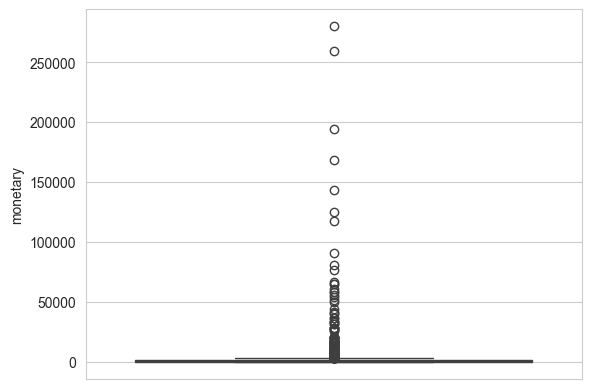

In [43]:
# 1. Outlier Treatment
sns.boxplot(y=grouped_df["monetary"])
plt.show()

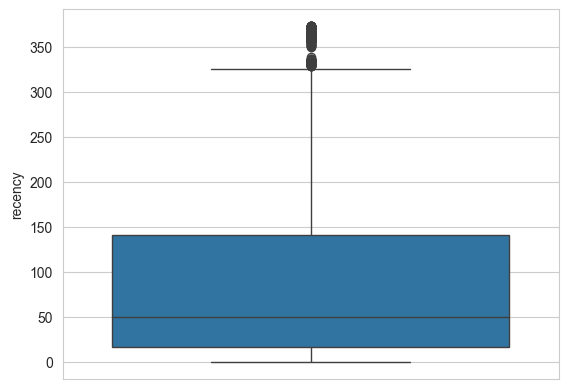

In [44]:
sns.boxplot(y=grouped_df["recency"])
plt.show()

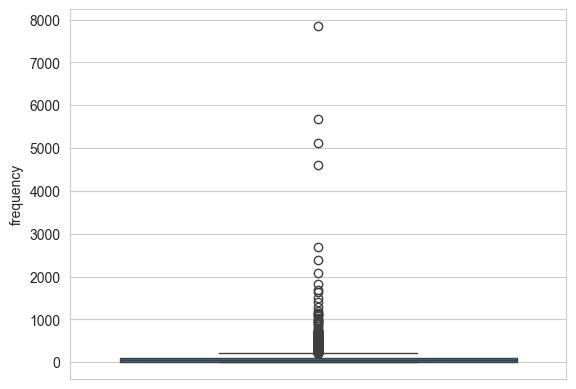

In [45]:
sns.boxplot(y=grouped_df["frequency"])
plt.show()

#### Outlier Treatment is of two types:
1. Domain Specific
2. Statisitical

It basically depends on what we want to present to our client.

Here we will it as is for now, when the client asks for it

In [46]:
# Removing (Statistical) Outliers
def removing_statistcal_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.05)
        Q3 = df[col].quantile(0.95)
        IQR = Q3 - Q1
        # print(f"Original Shape: {grouped_df.shape}")
        df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]
        # print(f"After Removing Outliers: {grouped_df.shape}")
    return df

In [47]:
grouped_df = removing_statistcal_outliers(grouped_df, grouped_df.columns)
print(grouped_df.shape)
grouped_df.head()

(4255, 4)


,CustomerID,frequency,monetary,recency
1,12347.0,182,4310.00,1
2,12348.0,31,1797.24,74
3,12349.0,73,1757.55,18
4,12350.0,17,334.40,309
5,12352.0,85,2506.04,35


In [48]:
rfm_dm = grouped_df[["recency", "frequency", "monetary"]]
scaler = StandardScaler()
rfm_dm_rescaled = scaler.fit_transform(rfm_dm)
rfm_dm_rescaled.shape

(4255, 3)

In [49]:
# Hopkins Statistics
from sklearn.neighbors import NearestNeighbors
from random import sample
from numpy.random import uniform

from math import isnan


def hopkins(X):
    d = X.shape[1]
    # d = len(vars) # columns
    n = len(X)  # rows
    m = int(0.1 * n)
    nbrs = NearestNeighbors(n_neighbors=1).fit(X.values)

    rand_X = sample(range(0, n, 1), m)

    ujd = []  # these are adjacency lists
    wjd = []
    for j in range(0, m):
        u_dist, _ = nbrs.kneighbors(
            uniform(np.amin(X, axis=0), np.amax(X, axis=0), d).reshape(1, -1),
            2,
            return_distance=True,
        )
        ujd.append(u_dist[0][1])  # adjacency list??
        w_dist, _ = nbrs.kneighbors(
            X.iloc[rand_X[j]].values.reshape(1, -1), 2, return_distance=True
        )
        wjd.append(w_dist[0][1])
    # print(ujd)
    H = sum(ujd) / (sum(ujd) + sum(wjd))
    print(round(H, 3))
    if isnan(H):
        print(ujd, wjd)
        H = 0

    return round(H, 3)

In [50]:
rfm_df_scaled = pd.DataFrame(rfm_dm_rescaled)
rfm_df_scaled.columns = ["frequency", "amount", "recency"]

In [51]:
print(hopkins(rfm_df_scaled))

0.947
0.947


Notes regarding Hopkins Statistic

- You don't need to know how the algorithm of  Hopkins Statistic works. The algorithm is pretty advanced and hence you don't need to know its workings but rather only interpret the value that it assigns to the dataframe.
- On multiple iterations of Hopkins Statistic, you would be getting multiple values since the algorithm uses some randomisation in the initialisation part of the code. Therefore it is advised to run it a couple of times before confirming whether the data is suitable for clustering or not.m

## 4. Modelling

In [52]:
# k means with some random k
# from importlib import reload
# reload(sklearn.cluster)
kmeans = KMeans(n_clusters=4, max_iter=50000)

In [53]:
kmeans.fit(rfm_df_scaled)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,50000
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [54]:
kmeans.labels_

array([2, 0, 0, ..., 0, 1, 0], shape=(4255,), dtype=int32)

## Finding the optimal number of clusters

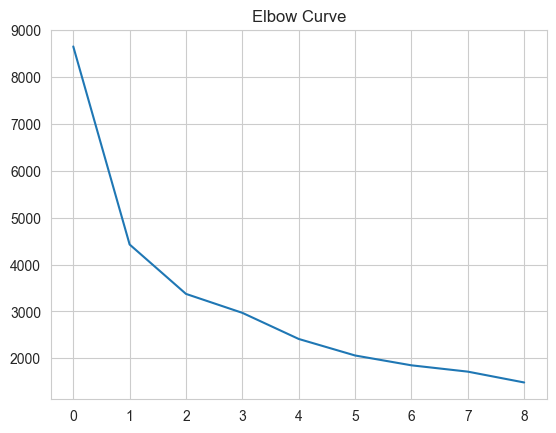

In [55]:
# elbow-curve/L2-Distance
l2_distances = []
range_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]
for el in range_clusters:
    kmeans = KMeans(n_clusters=el, max_iter=5000)
    kmeans.fit(rfm_df_scaled)
    l2_distances.append(kmeans.inertia_)
# Plot the L2 distances
plt.plot(l2_distances)
# plt.xlabel(range_clusters)
plt.title("Elbow Curve")
plt.show()

### Silhouette Analysis

$$\text{silhouette score}=\frac{p-q}{max(p,q)}$$

$p$ is the mean distance to the points in the nearest cluster that the data point is not a part of

$q$ is the mean intra-cluster distance to all the points in its own cluster.

* The value of the silhouette score range lies between -1 to 1.

* A score closer to 1 indicates that the data point is very similar to other data points in the cluster,

* A score closer to -1 indicates that the data point is not similar to the data points in its cluster.


8. K-Means Clustering - Plotting the Graph using Elbow Method
We prepare the dataset for clustering by dropping the 'Country' column.
* The Elbow Method is employed to determine the optimal number of clusters for K-Means.
* The Yellowbrick library's KElbowVisualizer is utilized to visualize the elbow plot.
* K-Means clustering is performed with the chosen number of clusters, and cluster assignments are added to the DataFrame.
* The centroids of the clusters are computed and displayed.



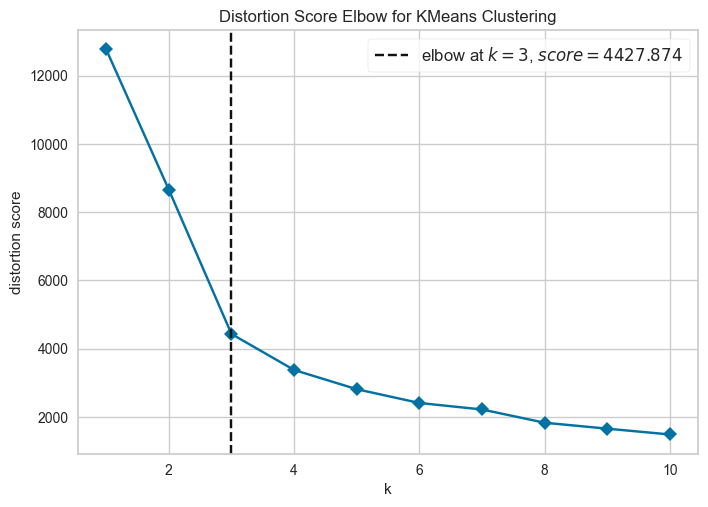

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [56]:
from yellowbrick.cluster import KElbowVisualizer

model = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(model, k=(1, 11), timings=False)
visualizer.fit(rfm_df_scaled)  # Fit data to visualizer
visualizer.show()

## Hierarchical Clustering
Using silhouette scorem

In [57]:
from sklearn.metrics import silhouette_samples, silhouette_score

score = silhouette_score(rfm_df_scaled, model.labels_, metric="euclidean")
print(f"silhouette Score: {score}")

from sklearn.cluster import AgglomerativeClustering

hierarchial = AgglomerativeClustering(n_clusters=3)
y_predicted_hierarchial = hierarchial.fit_predict(rfm_df_scaled)
rfm_df_scaled["clusters_hierarchial"] = y_predicted_hierarchial
rfm_df_scaled.head(30)

silhouette Score: 0.3777064003907874


,frequency,amount,recency,clusters_hierarchial
0,-0.918198,1.054741,1.686536,0
1,-0.189650,-0.457997,0.272949,2
2,-0.748536,-0.037235,0.250621,0
3,2.155675,-0.598251,-0.549991,1
4,-0.578874,0.082982,0.671694,0
5,1.097784,-0.728486,-0.688044,1
6,1.377227,-0.187507,-0.130881,1
7,1.197585,-0.638323,-0.479670,1
8,-0.708616,-0.177489,0.843495,0
9,-0.608815,0.543816,2.754095,0


<Axes: xlabel='clusters_hierarchial'>

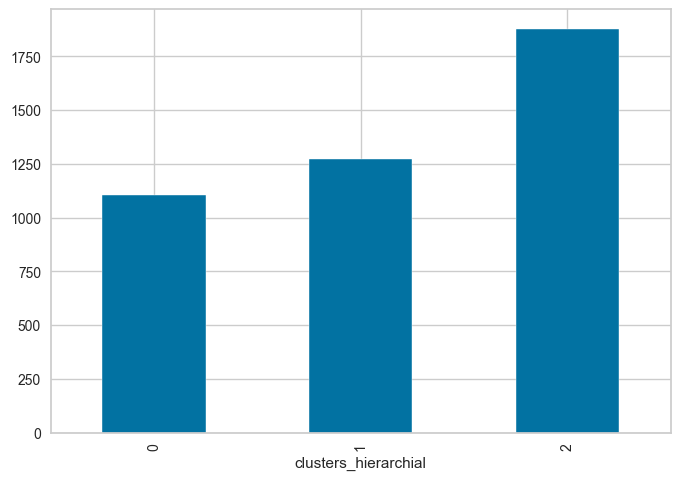

In [58]:
rfm_df_scaled.groupby("clusters_hierarchial")["frequency"].count().plot.bar()

In [59]:
ssd = []
for el in range_clusters:
    kmeans = KMeans(n_clusters=el, max_iter=50)
    kmeans.fit(rfm_df_scaled)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(rfm_df_scaled, cluster_labels)
    print(f"For {el} clusters the silhouette score is {silhouette_avg}")

For 2 clusters the silhouette score is 0.3503229096084776
For 3 clusters the silhouette score is 0.5435841857311985
For 4 clusters the silhouette score is 0.4937819915221403
For 5 clusters the silhouette score is 0.5255313521125098
For 6 clusters the silhouette score is 0.5690956926826768
For 7 clusters the silhouette score is 0.3974728299317242
For 8 clusters the silhouette score is 0.39954345559157584
For 9 clusters the silhouette score is 0.509759301267485
For 10 clusters the silhouette score is 0.3894420715306129


In [60]:
kmeans = KMeans(n_clusters=3, max_iter=500)
kmeans.fit(rfm_df_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,500
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [61]:
kmeans.labels_

array([2, 0, 2, ..., 0, 2, 0], shape=(4255,), dtype=int32)

In [62]:
grouped_df["cluster_id"] = kmeans.labels_

In [63]:
grouped_df.head(10)

,CustomerID,frequency,monetary,recency,cluster_id
1,12347.0,182,4310.00,1,2
2,12348.0,31,1797.24,74,0
3,12349.0,73,1757.55,18,2
4,12350.0,17,334.40,309,1
5,12352.0,85,2506.04,35,2
6,12353.0,4,89.00,203,1
7,12354.0,58,1079.40,231,1
8,12355.0,13,459.40,213,1
9,12356.0,59,2811.43,22,2
10,12357.0,131,6207.67,32,2


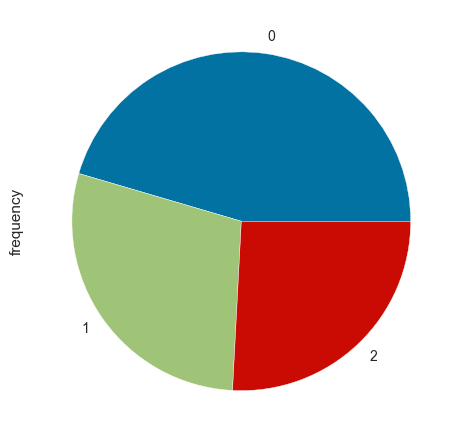

In [64]:
grouped_df.groupby("cluster_id")["frequency"].count().plot.pie()
plt.show()

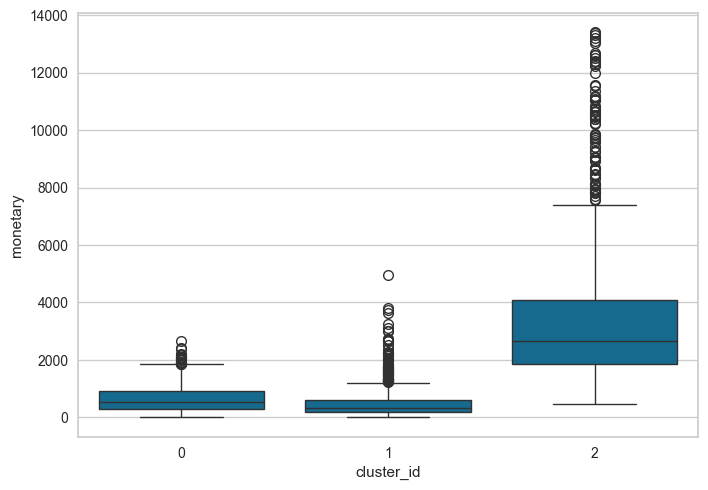

In [66]:
sns.boxplot(x="cluster_id", y="monetary", data=grouped_df)
plt.show()

In [70]:
rfm_df_scaled.describe()

,frequency,amount,recency,clusters_hierarchial
count,4.255000e+03,4.255000e+03,4.255000e+03,4255.000000
mean,-6.429118e-17,3.506791e-17,-8.015523e-17,1.180729
std,1.000118e+00,1.000118e+00,1.000118e+00,0.817363
min,-9.281782e-01,-7.585407e-01,-7.360023e-01,0.000000
25%,-7.485362e-01,-5.982506e-01,-5.668902e-01,0.000000
50%,-4.191927e-01,-3.678337e-01,-3.683784e-01,1.000000
75%,5.089574e-01,1.931815e-01,1.448424e-01,2.000000
max,2.794402e+00,6.805146e+00,6.800371e+00,2.000000


## Hierarchical Clustering

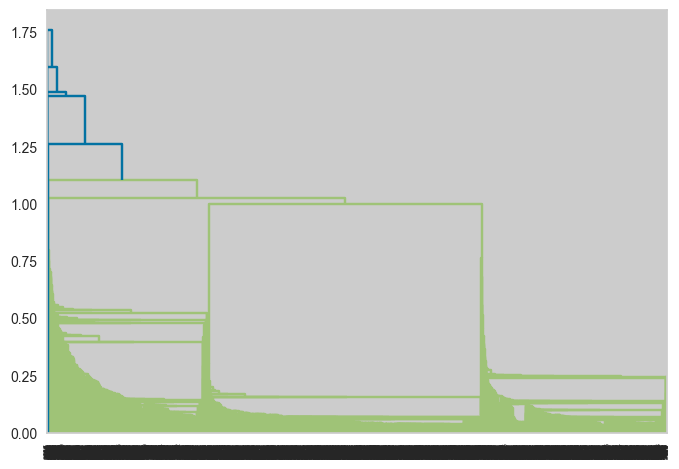

In [78]:
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree

mergings = linkage(rfm_df_scaled, method="single", metric="euclidean")
dendrogram(mergings)
plt.show()

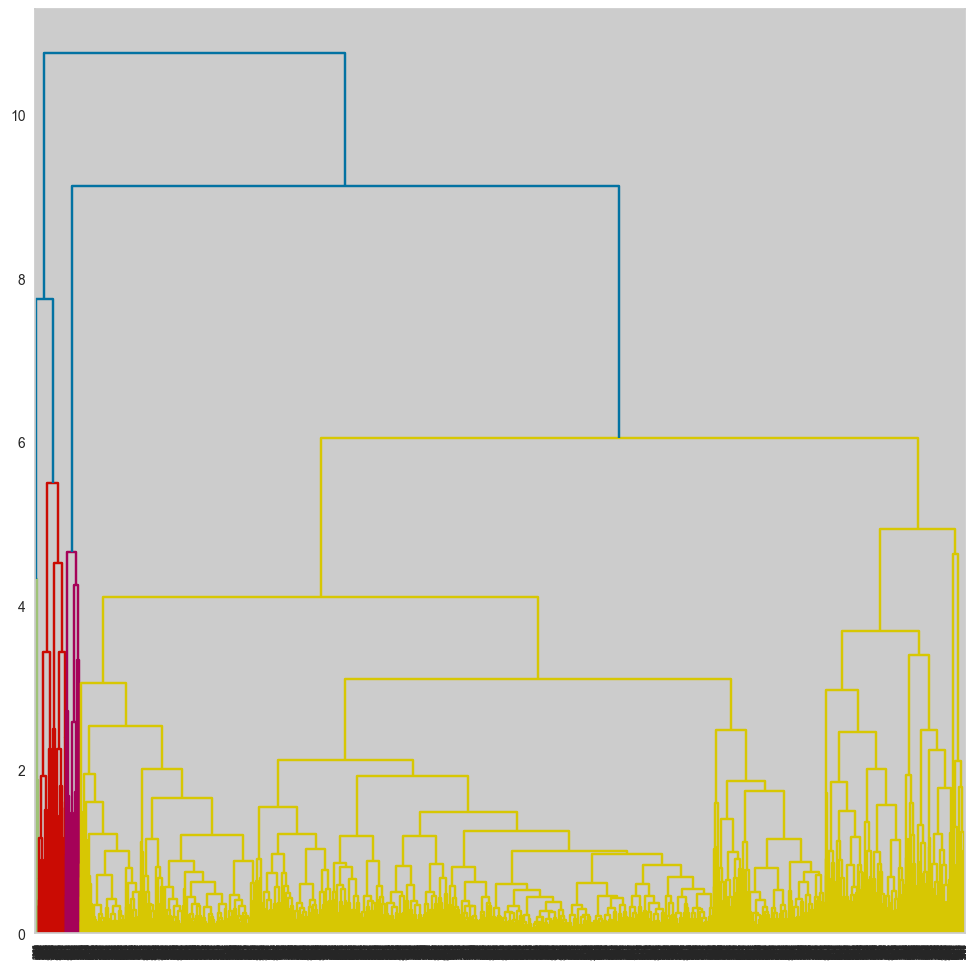

In [83]:
mergings = linkage(rfm_dm_rescaled, method="complete", metric="euclidean")
plt.figure(figsize=(12, 12))
dendrogram(mergings)
plt.show()

In [81]:
cluster_labels = cut_tree(mergings, n_clusters=3).reshape(
    -1,
)
cluster_labels

array([0, 0, 0, ..., 0, 0, 0], shape=(4255,))

In [82]:
grouped_df["cluster_labels"] = cluster_labels
grouped_df.head(10)

,CustomerID,frequency,monetary,recency,cluster_id,cluster_labels
1,12347.0,182,4310.00,1,2,0
2,12348.0,31,1797.24,74,0,0
3,12349.0,73,1757.55,18,2,0
4,12350.0,17,334.40,309,1,0
5,12352.0,85,2506.04,35,2,0
6,12353.0,4,89.00,203,1,0
7,12354.0,58,1079.40,231,1,0
8,12355.0,13,459.40,213,1,0
9,12356.0,59,2811.43,22,2,0
10,12357.0,131,6207.67,32,2,0


<Axes: xlabel='cluster_labels', ylabel='monetary'>

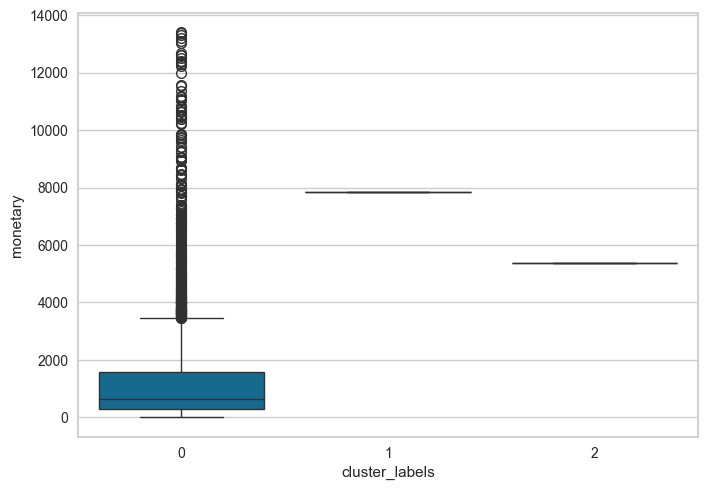

In [90]:
sns.boxplot(data=grouped_df, x="cluster_labels", y="monetary")

<Axes: xlabel='cluster_labels', ylabel='recency'>

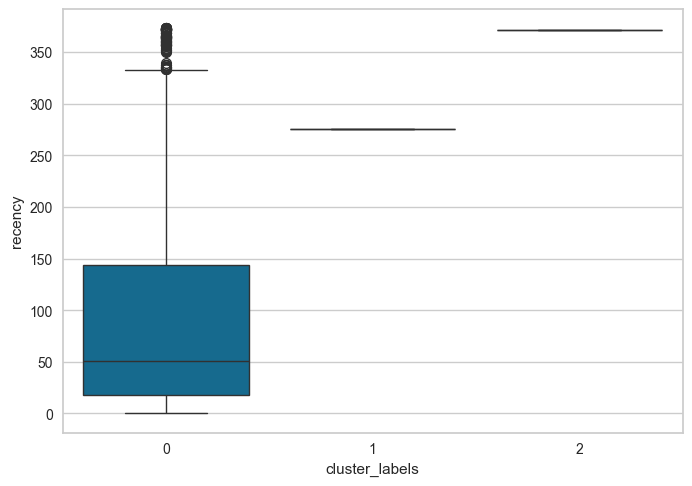

In [91]:
sns.boxplot(data=grouped_df, x="cluster_labels", y="recency")

<Axes: xlabel='cluster_labels', ylabel='frequency'>

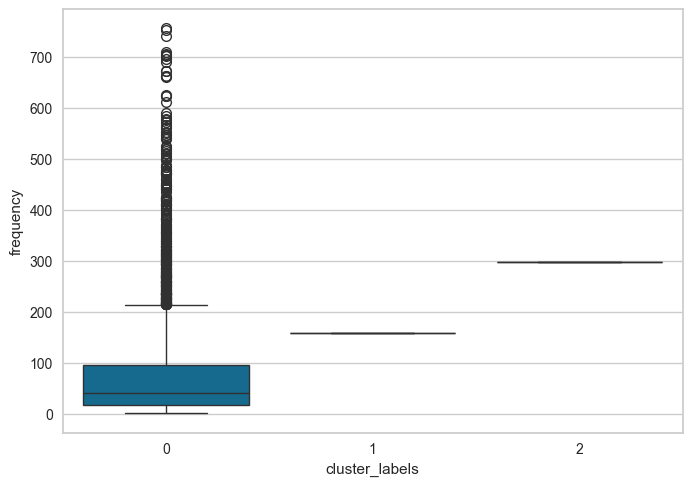

In [92]:
sns.boxplot(data=grouped_df, x="cluster_labels", y="frequency")

<Axes: xlabel='cluster_labels', ylabel='recency'>

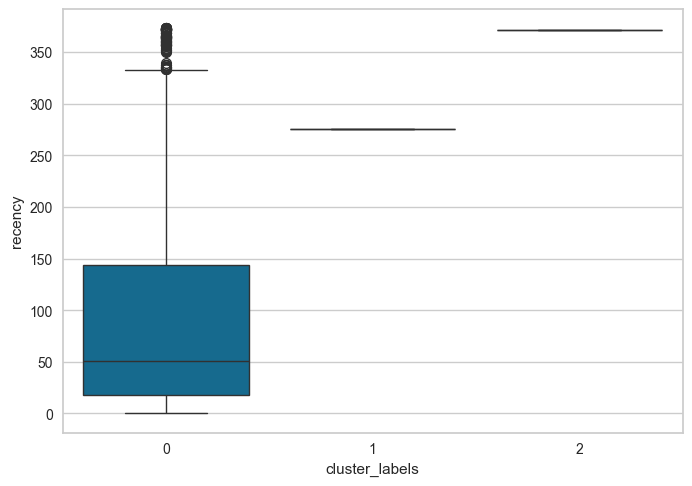

In [93]:
sns.boxplot(x="cluster_labels", y="recency", data=grouped_df)